# 02. Auditoria e Análise Exploratória de Dados (AED) - Conjunto Histórico (D0)

Este notebook realiza a auditoria e a análise descritiva da base histórica (D0), conforme as seções 6.1 e 6.2 do edital:
* Auditoria de valores faltantes, tipos e cardinalidade.
* Verificação do balanceamento da variável-alvo (`target_trend_up`).
* Distribuição das variáveis contínuas e sua relação com o comportamento de subida no ranking.
* Matriz de correlação linear das variáveis explicativas.
* Comparação aprofundada de comportamento entre os 5 mercados analisados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Carregamento exclusivo de D0
d0 = pd.read_csv('../data/processed/d0.csv')
d0['date'] = pd.to_datetime(d0['date'])
print(f"D0 carregado com {d0.shape[0]:,} linhas e {d0.shape[1]} colunas.")

D0 carregado com 163,932 linhas e 23 colunas.


## 1. Auditoria de Integridade dos Dados

Verificação de tipos de dados, volume de valores ausentes e contagem de categorias únicas por atributo.

In [2]:
audit_df = pd.DataFrame({
    'Tipo': d0.dtypes,
    'Valores Nulos': d0.isnull().sum(),
    'Proporção Nulos (%)': (d0.isnull().sum() / len(d0)) * 100,
    'Valores Únicos': d0.nunique()
})
display(audit_df)

,Tipo,Valores Nulos,Proporção Nulos (%),Valores Únicos
date,datetime64[us],0,0.000000,176
country,str,0,0.000000,5
rank,int64,0,0.000000,200
uri,str,0,0.000000,3177
album_name,str,0,0.000000,2960
artist_names,str,0,0.000000,1495
label,str,0,0.000000,1000
peak_rank,int64,0,0.000000,200
previous_rank,int64,0,0.000000,201
weeks_on_chart,int64,0,0.000000,177


## 1.1 Síntese Consolidada da Auditoria de Dados (Item 6.1 do Edital)

A tabela abaixo consolida os resultados quantitativos da auditoria estrutural e de integridade dos dados, comparando a base de dados bruta com a base tratada e particionada. Esse resumo documenta o volume de instâncias, o tratamento de valores faltantes/nulos, a dimensionalidade antes e depois da engenharia de atributos, e a proporção de corte temporal estabelecida.

**Nota sobre identificadores (RN03.2):** as colunas `uri`, `artist_uris` e `album_name`/`artist_names` são mantidas na base apenas para fins de auditoria, rastreabilidade e análise de erros (Notebook 04); elas **não** são utilizadas como variáveis de entrada dos modelos, conforme tratado em `TemporalPreprocessor`.

In [3]:
import glob
import os
import pandas as pd

# 1. Carregamento dos dados brutos originais para comparação
raw_files = glob.glob('../data/raw/*.csv')
if not raw_files:
    raise FileNotFoundError("Nenhum arquivo CSV encontrado na pasta ../data/raw/")

df_raw_audit = pd.read_csv(raw_files[0])

# 2. Carregamento das três partições processadas
d0_audit = pd.read_csv('../data/processed/d0.csv')
d1_audit = pd.read_csv('../data/processed/d1.csv')
d2_audit = pd.read_csv('../data/processed/d2.csv')

total_processado = len(d0_audit) + len(d1_audit) + len(d2_audit)
total_nulos_bruto = int(df_raw_audit.isnull().sum().sum())

# 3. Construção do Relatório Consolidado
relatorio_auditoria = pd.DataFrame([
    {
        "Métrica / Etapa": "Instâncias Iniciais (Base Bruta)",
        "Valor": f"{len(df_raw_audit):,}",
        "Descrição": "Total de linhas no arquivo original consolidado dos 5 países"
    },
    {
        "Métrica / Etapa": "Instâncias Finais Válidas",
        "Valor": f"{total_processado:,}",
        "Descrição": "Total mantido após remoção do último ciclo temporal sem target"
    },
    {
        "Métrica / Etapa": "Tratamento de Valores Nulos",
        "Valor": f"{total_nulos_bruto:,} tratados",
        "Descrição": "Imputação temporal em datas e descarte de borda do shift(-1)"
    },
    {
        "Métrica / Etapa": "Dimensionalidade Inicial",
        "Valor": f"{df_raw_audit.shape[1]} colunas",
        "Descrição": "Atributos originais brutos presentes no arquivo Kaggle"
    },
    {
        "Métrica / Etapa": "Dimensionalidade Final",
        "Valor": f"{d0_audit.shape[1]} colunas",
        "Descrição": "Colunas após criação do target e das variáveis explicativas"
    },
    {
        "Métrica / Etapa": "Particionamento D0 / D1 / D2",
        "Valor": f"{len(d0_audit):,} / {len(d1_audit):,} / {len(d2_audit):,}",
        "Descrição": f"Proporções cronológicas: {len(d0_audit)/total_processado:.1%} / {len(d1_audit)/total_processado:.1%} / {len(d2_audit)/total_processado:.1%}"
    }
])

# 4. Exibição da tabela consolidada
print("=" * 60)
print("       RELATÓRIO RESUMIDO DE AUDITORIA DE DADOS (US03)      ")
print("=" * 60)
display(relatorio_auditoria)

       RELATÓRIO RESUMIDO DE AUDITORIA DE DADOS (US03)      


,Métrica / Etapa,Valor,Descrição
0,Instâncias Iniciais (Base Bruta),"281,588",Total de linhas no arquivo original consolidad...
1,Instâncias Finais Válidas,"272,779",Total mantido após remoção do último ciclo tem...
2,Tratamento de Valores Nulos,"6,637 tratados",Imputação temporal em datas e descarte de bord...
3,Dimensionalidade Inicial,17 colunas,Atributos originais brutos presentes no arquiv...
4,Dimensionalidade Final,23 colunas,Colunas após criação do target e das variáveis...
5,Particionamento D0 / D1 / D2,"163,932 / 57,497 / 51,350",Proporções cronológicas: 60.1% / 21.1% / 18.8%


## 2. Balanceamento da Variável-Alvo

Examinamos a proporção de casos em que os álbuns sobem de ranking (classe 1) versus casos em que caem ou se mantêm (classe 0).

Classe 0 (Caiu/Manteve): 104,257 registros (63.60%)
Classe 1 (Subiu)       : 59,675 registros (36.40%)


C:\Users\55449\AppData\Local\Temp\ipykernel_13540\2107724260.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Caiu / Manteve (0)', 'Subiu (1)'], y=target_counts.values, palette=['#4A90E2', '#50E3C2'])


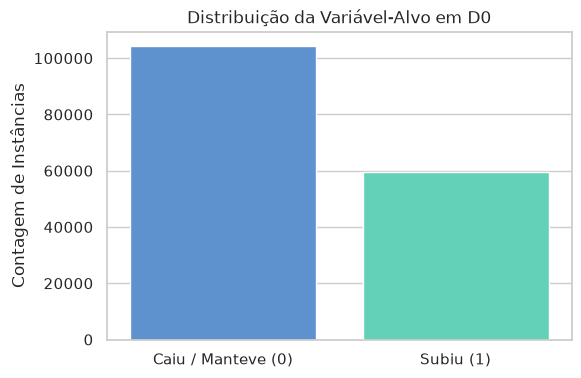

In [4]:
target_counts = d0['target_trend_up'].value_counts()
target_pct = d0['target_trend_up'].value_counts(normalize=True) * 100

print(f"Classe 0 (Caiu/Manteve): {target_counts[0]:,} registros ({target_pct[0]:.2f}%)")
print(f"Classe 1 (Subiu)       : {target_counts[1]:,} registros ({target_pct[1]:.2f}%)")

plt.figure(figsize=(6, 4))
sns.barplot(x=['Caiu / Manteve (0)', 'Subiu (1)'], y=target_counts.values, palette=['#4A90E2', '#50E3C2'])
plt.title("Distribuição da Variável-Alvo em D0")
plt.ylabel("Contagem de Instâncias")
plt.show()

## 3. Distribuições Numéricas e Comportamento por País

Avaliamos o comportamento das variáveis explicativas em relação à ascensão do álbum e as taxas médias de subida entre os países.

C:\Users\55449\AppData\Local\Temp\ipykernel_13540\119047387.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d0, x='target_trend_up', y='album_age_days', showfliers=False, ax=axes[0], palette=['#4A90E2', '#50E3C2'])
C:\Users\55449\AppData\Local\Temp\ipykernel_13540\119047387.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Caiu / Manteve (0)', 'Subiu (1)'])
C:\Users\55449\AppData\Local\Temp\ipykernel_13540\119047387.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_perf, x='country', y='target_trend_up', ax=axes[1], pal

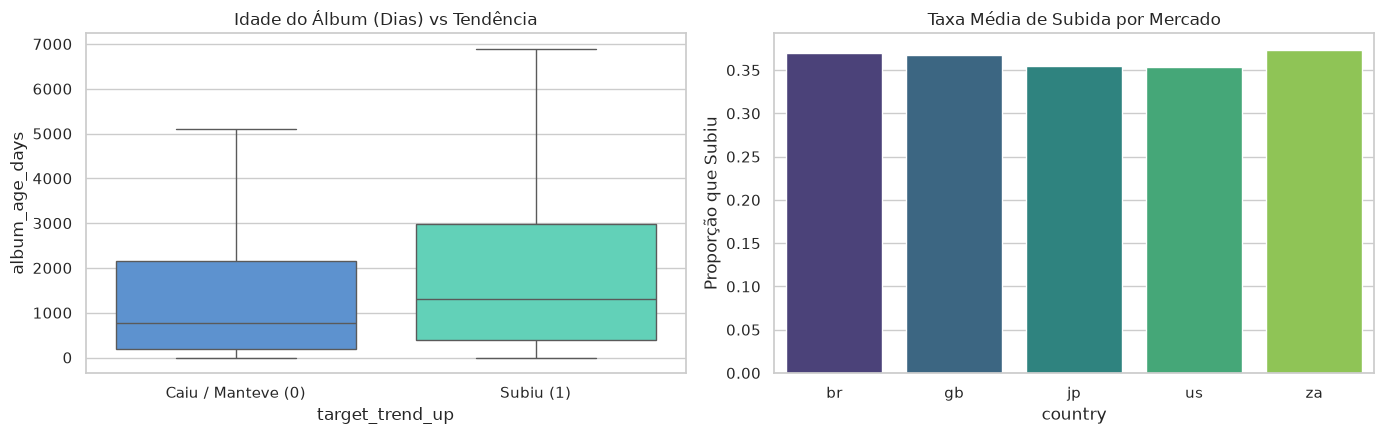

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Idade do álbum vs subida no ranking
sns.boxplot(data=d0, x='target_trend_up', y='album_age_days', showfliers=False, ax=axes[0], palette=['#4A90E2', '#50E3C2'])
axes[0].set_title("Idade do Álbum (Dias) vs Tendência")
axes[0].set_xticklabels(['Caiu / Manteve (0)', 'Subiu (1)'])

# Taxa de subida média por país
country_perf = d0.groupby('country')['target_trend_up'].mean().reset_index()
sns.barplot(data=country_perf, x='country', y='target_trend_up', ax=axes[1], palette='viridis')
axes[1].set_title("Taxa Média de Subida por Mercado")
axes[1].set_ylabel("Proporção que Subiu")

plt.tight_layout()
plt.show()

## 4. Matriz de Correlação Linear

Verificamos a correlação entre as variáveis explicativas e o target para diagnosticar multicolinearidade prévia.

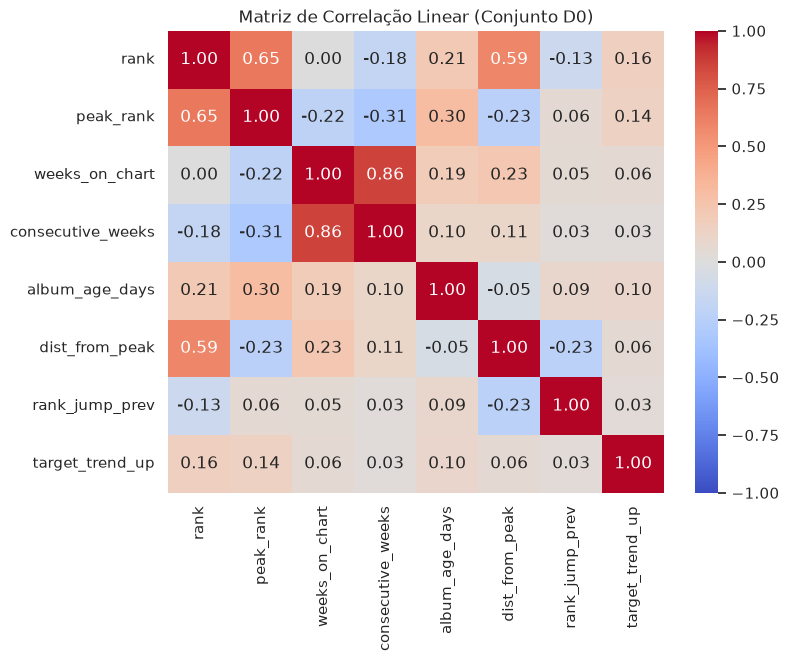

In [6]:
num_cols = [
    'rank', 'peak_rank', 'weeks_on_chart', 'consecutive_weeks',
    'album_age_days', 'dist_from_peak', 'rank_jump_prev', 'target_trend_up'
]

plt.figure(figsize=(8, 6))
corr = d0[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação Linear (Conjunto D0)")
plt.show()

## 5. Comparativo Aprofundado entre os 5 Mercados (RN03.2)

O edital exige que a AED discuta explicitamente as diferenças de comportamento de consumo entre os países. Nesta seção comparamos: (a) volume relativo de registros por país, (b) evolução temporal da taxa de subida por mercado, e (c) perfil de idade média dos álbuns populares em cada país — o que ajuda a entender diferenças culturais de consumo (ex: mercados que priorizam lançamentos recentes vs. catálogo antigo).

C:\Users\55449\AppData\Local\Temp\ipykernel_13540\3646716110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_volume.index, y=country_volume.values, ax=axes[0], palette='crest')
C:\Users\55449\AppData\Local\Temp\ipykernel_13540\3646716110.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top50_by_country, x='country', y='album_age_days', ax=axes[2], palette='flare')


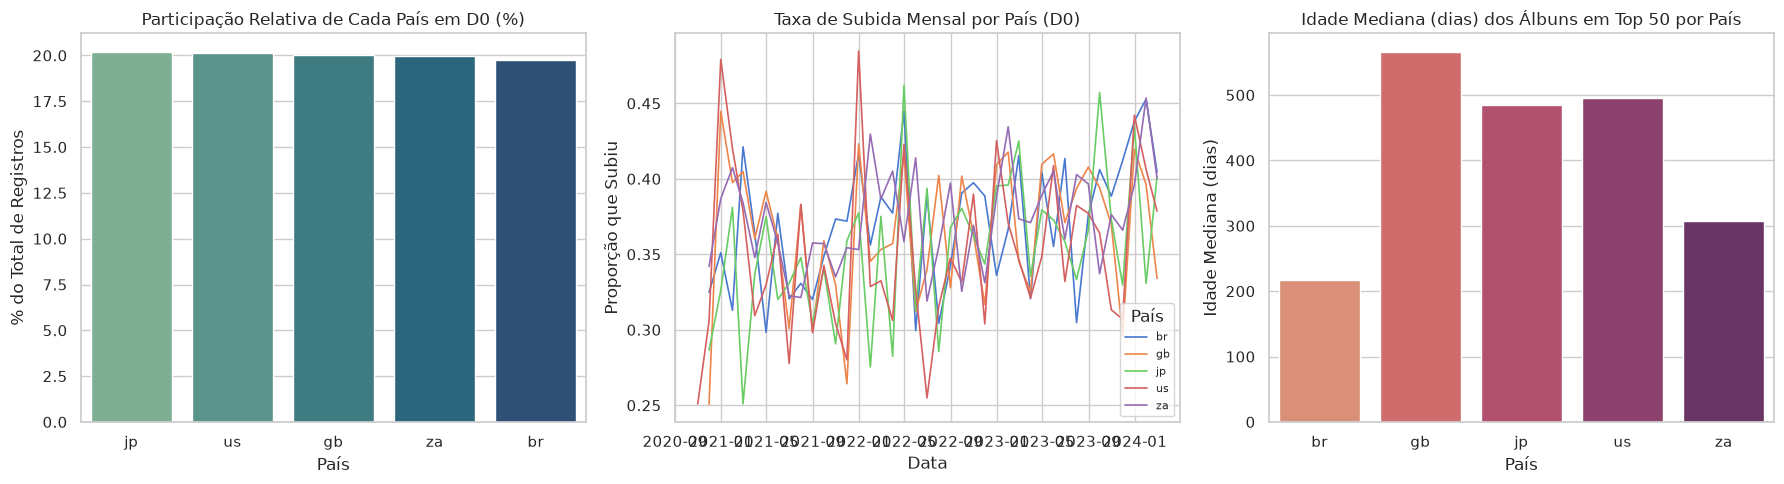

Interpretação sugerida: mercados com álbuns 'Top 50' de idade mediana muito baixa indicam
consumo voltado a lançamentos recentes; mercados com idade mediana alta sugerem forte presença
de catálogo (nostalgia/clássicos) na lista de mais ouvidos.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Volume relativo de registros por país em D0
country_volume = d0['country'].value_counts(normalize=True) * 100
sns.barplot(x=country_volume.index, y=country_volume.values, ax=axes[0], palette='crest')
axes[0].set_title("Participação Relativa de Cada País em D0 (%)")
axes[0].set_ylabel("% do Total de Registros")
axes[0].set_xlabel("País")

# (b) Evolução temporal da taxa de subida por mercado (agregado mensal)
d0_monthly = d0.set_index('date').groupby('country')['target_trend_up'].resample('ME').mean().reset_index()
sns.lineplot(data=d0_monthly, x='date', y='target_trend_up', hue='country', ax=axes[1], linewidth=1.2)
axes[1].set_title("Taxa de Subida Mensal por País (D0)")
axes[1].set_ylabel("Proporção que Subiu")
axes[1].set_xlabel("Data")
axes[1].legend(title="País", fontsize=8)

# (c) Idade média dos álbuns populares (Top 50) por país
top50_by_country = d0[d0['is_top_50'] == 1].groupby('country')['album_age_days'].median().reset_index()
sns.barplot(data=top50_by_country, x='country', y='album_age_days', ax=axes[2], palette='flare')
axes[2].set_title("Idade Mediana (dias) dos Álbuns em Top 50 por País")
axes[2].set_ylabel("Idade Mediana (dias)")
axes[2].set_xlabel("País")

plt.tight_layout()
plt.show()

print("Interpretação sugerida: mercados com álbuns 'Top 50' de idade mediana muito baixa indicam")
print("consumo voltado a lançamentos recentes; mercados com idade mediana alta sugerem forte presença")
print("de catálogo (nostalgia/clássicos) na lista de mais ouvidos.")